In [3]:
# Cell 1: Setup
import findspark
findspark.init()

from pyspark.sql import SparkSession, functions as F
import os

spark = SparkSession.builder \
    .appName("Arabic-AI-Detection-AraBERT") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f" Spark {spark.version}")
print(f" Python: {__import__('sys').version.split()[0]}")

26/05/19 07:35:42 WARN Utils: Your hostname, localhost.localdomain resolves to a loopback address: 127.0.0.1; using 192.168.1.26 instead (on interface enp0s3)
26/05/19 07:35:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 07:35:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/19 07:35:44 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/19 07:35:44 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/05/19 07:35:44 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


 Spark 3.5.8
 Python: 3.12.13


In [4]:
# Cell 2: Load AraBERT
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "aubmindlab/bert-base-arabertv02"

print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()  


device = torch.device("cpu")
model.to(device)

print(f" AraBERT loaded on {device}")
print(f"  Model size: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parameters")

Loading aubmindlab/bert-base-arabertv02...
 AraBERT loaded on cpu
  Model size: 135.2M parameters


In [5]:
# Cell 3: Load sample 
HDFS_FEATURES_ALL = "hdfs://localhost:9000/user/hadoop/arabic-ai-detection/features_all.parquet"
df = spark.read.parquet(HDFS_FEATURES_ALL)


df_human = df.filter(F.col("label") == 0).orderBy(F.rand(seed=42)).limit(400)
df_ai    = df.filter(F.col("label") == 1).orderBy(F.rand(seed=42)).limit(1600)
df_sample = df_human.union(df_ai)


pdf = df_sample.select("text", "text_clean", "label", "source").toPandas()
print(f" Sampled {len(pdf)} rows")
print(pdf['label'].value_counts())

26/05/19 07:35:58 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                                                                                

 Sampled 2000 rows
label
1    1600
0     400
Name: count, dtype: int64


In [6]:
# Cell 4: Compute AraBERT [CLS] embeddings 

import numpy as np
from tqdm import tqdm

@torch.no_grad()
def get_arabert_embedding(text, max_len=128):
   
    if not text or len(text) < 5:
        return np.zeros(768, dtype=np.float32)
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       max_length=max_len, padding=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
   
    return outputs.last_hidden_state[0, 0, :].cpu().numpy()


print(f"Extracting embeddings for {len(pdf)} docs...")
embeddings = []
for text in tqdm(pdf["text"].tolist(), desc="AraBERT"):
    emb = get_arabert_embedding(text)
    embeddings.append(emb)

embeddings = np.array(embeddings, dtype=np.float32)
print(f"\n Embeddings shape: {embeddings.shape}")


Extracting embeddings for 2000 docs...


AraBERT: 100%|██████████████████████████████████████████████████████████████████| 2000/2000 [03:41<00:00,  9.04it/s]



 Embeddings shape: (2000, 768)


In [7]:
# Cell 5: Save embeddings to local disk 
import os
os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/arabert_embeddings.npy", embeddings)
pdf[["text", "text_clean", "label", "source"]].to_csv(
    "../data/processed/arabert_sample.csv", index=False)

print(" Saved:")
print("  ../data/processed/arabert_embeddings.npy")
print("  ../data/processed/arabert_sample.csv")

 Saved:
  ../data/processed/arabert_embeddings.npy
  ../data/processed/arabert_sample.csv


Train: 1400 | Test: 600

Training Random Forest on AraBERT features...

Random Forest on AraBERT features (test set):
  Accuracy: 0.9333
  F1:       0.9588
  ROC-AUC:  0.9770

Confusion matrix:
[[ 94  26]
 [ 14 466]]


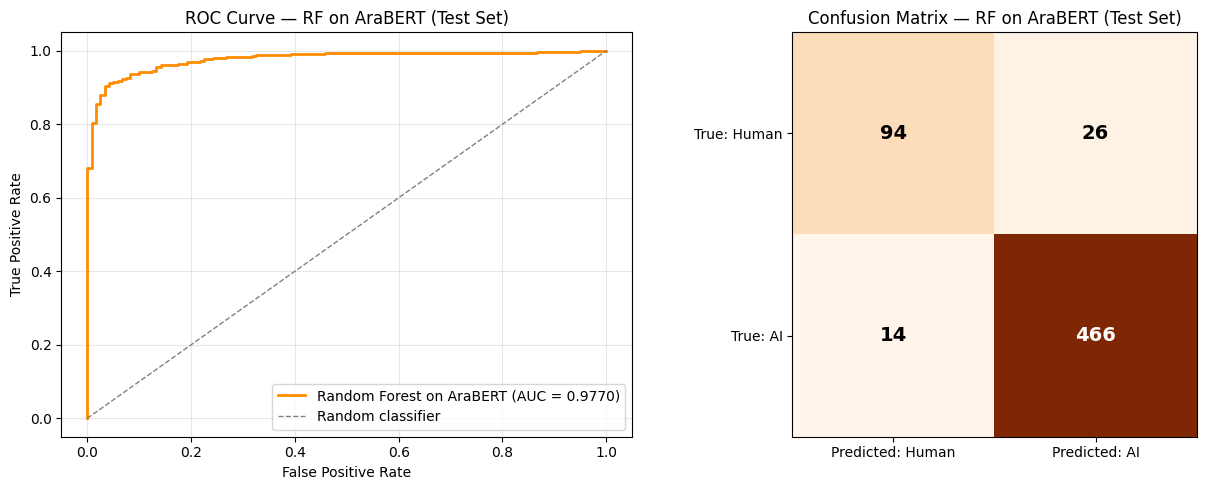

Saved figure to reports/figures/arabert_rf_results.png


In [8]:
# Cell 6: Train Random Forest on AraBERT embeddings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../reports/figures", exist_ok=True)


labels = pdf["label"].values
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.30, random_state=42, stratify=labels
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}\n")


print("Training Random Forest on AraBERT features...")
rf_arabert = RandomForestClassifier(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
rf_arabert.fit(X_train, y_train)


y_pred = rf_arabert.predict(X_test)
y_proba = rf_arabert.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"\nRandom Forest on AraBERT features (test set):")
print(f"  Accuracy: {acc:.4f}")
print(f"  F1:       {f1:.4f}")
print(f"  ROC-AUC:  {auc:.4f}")
print("\nConfusion matrix:")
print(cm)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))


fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"Random Forest on AraBERT (AUC = {auc:.4f})")
ax1.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve — RF on AraBERT (Test Set)")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)


im = ax2.imshow(cm, cmap="Oranges")
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(["Predicted: Human", "Predicted: AI"])
ax2.set_yticklabels(["True: Human", "True: AI"])
ax2.set_title("Confusion Matrix — RF on AraBERT (Test Set)")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        ax2.text(j, i, str(val), ha="center", va="center",
                 color="white" if val > cm.max()/2 else "black",
                 fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/arabert_rf_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to reports/figures/arabert_rf_results.png")

In [9]:
# Cell 7: Word2Vec vs AraBERT comparison table
import pandas as pd

comparison = pd.DataFrame([
    {"Embedding": "Word2Vec (100d, trained on corpus)",
     "Model": "Random Forest", "Test Acc": 0.9553, "Test F1": 0.9549, "Test AUC": 0.9888,
     "Train size": "29,625", "Notes": "Distributed, fast"},
    {"Embedding": "AraBERT (768d, pre-trained)",
     "Model": "Random Forest", "Test Acc": acc, "Test F1": f1, "Test AUC": auc,
     "Train size": f"{len(X_train)} (sample)", "Notes": "Heavy, contextualized"},
])

print("=" * 80)
print(" EMBEDDING COMPARISON: Word2Vec vs AraBERT")
print("=" * 80)
print(comparison.to_string(index=False))

comparison.to_csv("../reports/figures/embedding_comparison.csv", index=False)
print("\n Saved comparison to reports/figures/embedding_comparison.csv")

 EMBEDDING COMPARISON: Word2Vec vs AraBERT
                         Embedding         Model  Test Acc  Test F1  Test AUC    Train size                 Notes
Word2Vec (100d, trained on corpus) Random Forest  0.955300 0.954900  0.988800        29,625     Distributed, fast
       AraBERT (768d, pre-trained) Random Forest  0.933333 0.958848  0.976997 1400 (sample) Heavy, contextualized

 Saved comparison to reports/figures/embedding_comparison.csv
